In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons # just for fun
from scipy.stats import mode


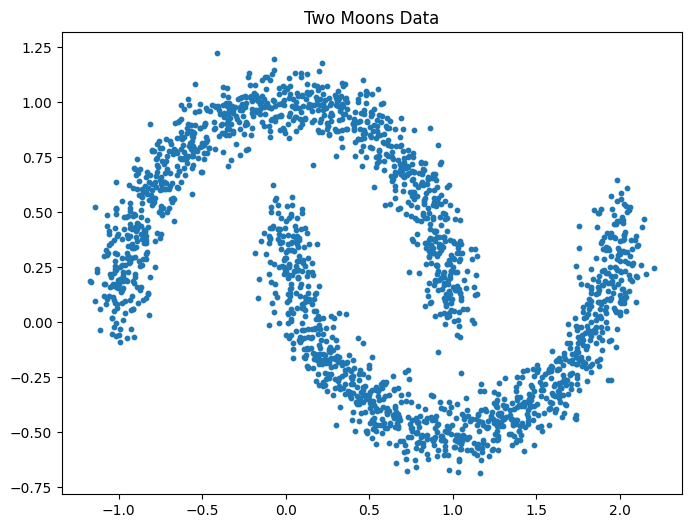

In [2]:
try:
    data = pd.read_csv('/kaggle/input/two-moon-kmeans-ex/two_moons_X_only.csv')
    X = data.values
except FileNotFoundError:
    print("File not found, generating synthetic data...")
    X, _ = make_moons(n_samples=2000, noise=0.05, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=10)
plt.title("Two Moons Data")
plt.show()

Final Centroids:
[[-0.20174088  0.57107305]
 [ 1.20611966 -0.07251765]]

Total Sum of Squared Errors (SSE): 817.1482


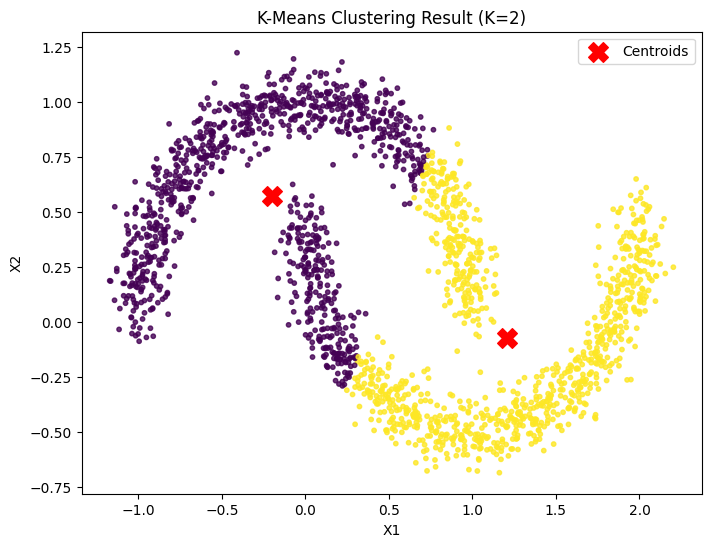

In [3]:
# Assuming X from the previous step is available

class KMeansFromScratch:
    """
    A simple implementation of the K-Means algorithm.
    """
    def __init__(self, K=2, max_iterations=100, random_seed=42):
        self.K = K
        self.max_iterations = max_iterations
        self.random_seed = random_seed
        self.centroids = []
        
    def _euclidean_distance(self, point1, point2):
        # Calculate the squared euclidean distance
        return np.sqrt(np.sum((point1 - point2)**2))

    def fit(self, X):
        num_samples, num_features = X.shape
        
        # Initialize centroids randomly from data points
        np.random.seed(self.random_seed)
        random_indices = np.random.choice(num_samples, self.K, replace=False)
        self.centroids = [X[idx] for idx in random_indices]
        
        # Main optimization loop
        for _ in range(self.max_iterations):
            # Assign samples to the closest centroid
            labels = self._assign_clusters(X)
            
            # Store old centroids to check for convergence
            old_centroids = self.centroids
            
            # Calculate new centroids
            self.centroids = self._update_centroids(X, labels)
            
            # Check for convergence
            if self._is_converged(old_centroids, self.centroids):
                break
        
        return labels

    def _assign_clusters(self, X):
        labels = np.empty(X.shape[0], dtype=int)
        for i, sample in enumerate(X):
            distances = [self._euclidean_distance(sample, centroid) for centroid in self.centroids]
            closest_centroid_idx = np.argmin(distances)
            labels[i] = closest_centroid_idx
        return labels

    def _update_centroids(self, X, labels):
        new_centroids = []
        for k in range(self.K):
            # Get all points assigned to this cluster
            points_in_cluster = X[labels == k]
            # Calculate the mean (new centroid)
            if len(points_in_cluster) > 0:
                mean_of_points = np.mean(points_in_cluster, axis=0)
                new_centroids.append(mean_of_points)
            else:
                # If a cluster is empty, keep its old centroid
                # A more robust solution might re-initialize it
                new_centroids.append(self.centroids[k])
        return new_centroids

    def _is_converged(self, old_centroids, new_centroids):
        # Check if the centroids have stopped moving
        distances = [self._euclidean_distance(old_centroids[i], new_centroids[i]) for i in range(self.K)]
        return sum(distances) == 0

def calculate_total_sse(X, labels, centroids):
    total_sse = 0
    for k in range(len(centroids)):
        cluster_points = X[labels == k]
        centroid = centroids[k]
        # Sum of squared distances for all points in this cluster
        sse_for_cluster = np.sum((cluster_points - centroid)**2)
        total_sse += sse_for_cluster
    return total_sse

# --- Execution ---
K = 2
kmeans_model = KMeansFromScratch(K=K, random_seed=42)
kmeans_labels = kmeans_model.fit(X)
kmeans_centroids = np.array(kmeans_model.centroids)

# Calculate Total SSE
total_sse_kmeans = calculate_total_sse(X, kmeans_labels, kmeans_centroids)

# Print the results
print(f"Final Centroids:\n{kmeans_centroids}")
print(f"\nTotal Sum of Squared Errors (SSE): {total_sse_kmeans:.4f}")

# Visualize the K-Means clustering result
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, s=10, cmap='viridis', alpha=0.8)
plt.scatter(kmeans_centroids[:, 0], kmeans_centroids[:, 1], c='red', s=200, marker='X', label='Centroids')
plt.title("K-Means Clustering Result (K=2)")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()


DBSCAN Results (Re-tuned):
Epsilon: 0.1
MinPts: 4
Number of clusters found: 2
Number of noise points: 5


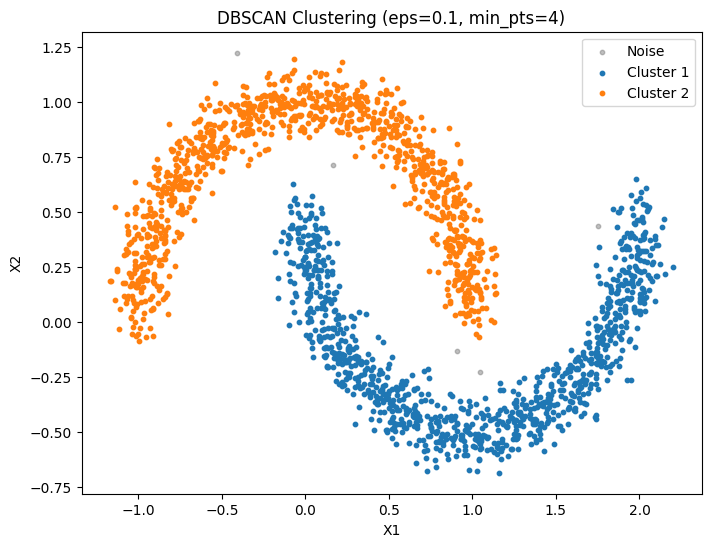

In [4]:

# Implementation of DBSCAN from scratch using functions
def get_neighbors(X, point_idx, eps):
    #Find indices of all points within distance eps from X[point_idx]
    neighbors = []
    # Loop through all points (inefficient but simple logic)
    for i in range(len(X)):
        dist = np.sqrt(np.sum((X[point_idx] - X[i])**2))
        if dist <= eps:
            neighbors.append(i)
    return neighbors

def expand_cluster(X, labels, point_idx, neighbors, cluster_id, eps, min_samples):
    # Assign the cluster label to the seed point
    labels[point_idx] = cluster_id
    
    i = 0
    while i < len(neighbors):
        neighbor_pt_idx = neighbors[i]
        
        #If this point was marked as noise, change it to border point of this cluster
        if labels[neighbor_pt_idx] == -1:
            labels[neighbor_pt_idx] = cluster_id
        
        #If point hasn't been visited yet
        elif labels[neighbor_pt_idx] == 0:
            labels[neighbor_pt_idx] = cluster_id
            
            # Find neighbors of this neighbor
            new_neighbors = get_neighbors(X, neighbor_pt_idx, eps)
            
            # If it has enough neighbors, it's a core point -> add its neighbors to queue
            if len(new_neighbors) >= min_samples:
                neighbors = neighbors + new_neighbors
        
        i += 1

def run_dbscan(X, eps, min_samples):
    # Labels: 0 means unvisited, -1 means noise, >0 means cluster ID
    labels = np.zeros(len(X), dtype=int)
    cluster_id = 0
    
    for i in range(len(X)):
        if labels[i] != 0:
            continue # Point already visited
        
        neighbors = get_neighbors(X, i, eps)
        
        if len(neighbors) < min_samples:
            # Mark as noise initially
            labels[i] = -1
        else:
            cluster_id += 1
            expand_cluster(X, labels, i, neighbors, cluster_id, eps, min_samples)
            
    return labels, cluster_id

eps_val = 0.1
min_pts_val = 4

dbscan_labels, num_clusters = run_dbscan(X, eps_val, min_pts_val)

# Calculating noise points 
n_noise = list(dbscan_labels).count(-1)

print(f"DBSCAN Results (Re-tuned):")
print(f"Epsilon: {eps_val}")
print(f"MinPts: {min_pts_val}")
print(f"Number of clusters found: {num_clusters}")
print(f"Number of noise points: {n_noise}")

# Plotting
plt.figure(figsize=(8, 6))
# Plot noise
noise_mask = dbscan_labels == -1
if np.any(noise_mask):
    plt.scatter(X[noise_mask, 0], X[noise_mask, 1], c='gray', s=10, label='Noise', alpha=0.5)

# Plot clusters
unique_clusters = set(dbscan_labels)
# Using a colormap to handle potentially more clusters or just distinct colors
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))

for i, k in enumerate(unique_clusters):
    if k != -1:
        mask = dbscan_labels == k
        plt.scatter(X[mask, 0], X[mask, 1], s=10, label=f'Cluster {k}')

plt.title(f"DBSCAN Clustering (eps={eps_val}, min_pts={min_pts_val})")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()


In [5]:
def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

def calculate_silhouette_from_scratch(X, labels):
   
    all_individual_scores = []
    
    unique_labels = set(labels)
    if -1 in unique_labels:
        unique_labels.remove(-1)

    # Go through each point to calculate its silhouette score
    for i in range(len(X)):
        my_label = labels[i]
        
        # IMPORTANT: Skip noise points as requested 
        if my_label == -1:
            continue

        # Calculate a(i)
        points_in_my_cluster = []
        for j in range(len(X)):
            if i != j and labels[j] == my_label:
                points_in_my_cluster.append(X[j])
        
        if not points_in_my_cluster:
            a_i = 0
        else:
            total_dist_a = 0
            for point in points_in_my_cluster:
                total_dist_a += euclidean_distance(X[i], point)
            a_i = total_dist_a / len(points_in_my_cluster)

        mean_distances_to_other_clusters = []
        
        other_labels = [l for l in unique_labels if l != my_label]
        
        for other_label in other_labels:
            points_in_other_cluster = []
            for k in range(len(X)):
                if labels[k] == other_label:
                    points_in_other_cluster.append(X[k])
            
            total_dist_b = 0
            for point in points_in_other_cluster:
                total_dist_b += euclidean_distance(X[i], point)
            
            # This should not happen with our data, but it's good practice
            if points_in_other_cluster:
                mean_dist = total_dist_b / len(points_in_other_cluster)
                mean_distances_to_other_clusters.append(mean_dist)
        
        if not mean_distances_to_other_clusters:
            # If there's only one cluster, score is 0
            b_i = 0
        else:
            b_i = min(mean_distances_to_other_clusters)
        
        if max(a_i, b_i) == 0:
            s_i = 0
        else:
            s_i = (b_i - a_i) / max(a_i, b_i)
        
        all_individual_scores.append(s_i)
        
    if not all_individual_scores:
        return 0 # In case all points are noise
        
    final_silhouette_score = sum(all_individual_scores) / len(all_individual_scores)
    return final_silhouette_score

# Calculate and Report Scores

# 1. For K-Means
kmeans_silhouette = calculate_silhouette_from_scratch(X, kmeans_labels)
print(f"K-Means Silhouette Score: {kmeans_silhouette:.4f}")

# 2. For DBSCAN (using best_labels, which already has noise filtered inside the function)
dbscan_silhouette = calculate_silhouette_from_scratch(X, dbscan_labels)
print(f"DBSCAN Silhouette Score (excluding noise): {dbscan_silhouette:.4f}")


K-Means Silhouette Score: 0.4867
DBSCAN Silhouette Score (excluding noise): 0.3326


Columns found in CSV: Index(['x', 'y', 'y_scrambled'], dtype='object')
Data types before conversion:
 x              float64
y              float64
y_scrambled      int64
dtype: object
First 5 rows of data:
           x         y  y_scrambled
0  1.802401  0.169535            1
1  0.407163  0.923460            0
2  0.496246 -0.327862            0
3 -0.950480  0.188680            0
4  0.465032 -0.328285            0

Data loaded and types corrected. Shape: (2000, 2)


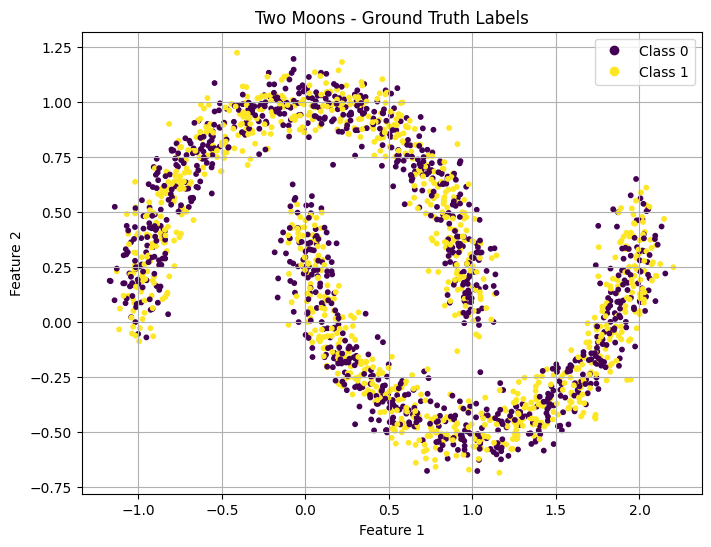

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = '/kaggle/input/two-moon-kmeans-ex/two_moons_scrambled_labels.csv'

labeled_df = pd.read_csv(file_path)

print("Columns found in CSV:", labeled_df.columns)
print("Data types before conversion:\n", labeled_df.dtypes)
print("First 5 rows of data:\n", labeled_df.head())
    
label_column_name = 'y_scrambled' 

y_true = labeled_df[label_column_name].astype(int).values
    
feature_columns = labeled_df.columns[:2]
X = labeled_df[feature_columns].values
    
print("\nData loaded and types corrected. Shape:", X.shape)

plt.style.use('default')
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y_true, 
    s=10,
    cmap='viridis'
)

plt.title("Two Moons - Ground Truth Labels")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(handles=scatter.legend_elements()[0], labels=['Class 0', 'Class 1'])
plt.grid(True)
plt.show()



In [7]:
def calculate_purity(y_true, y_pred):
    
    

    
    clustered_indices = np.where(y_pred != -1)[0]
    y_true_clustered = y_true[clustered_indices]
    y_pred_clustered = y_pred[clustered_indices]
    
    contingency_matrix = np.zeros((np.max(y_pred_clustered) + 1, np.max(y_true_clustered) + 1))
    
    for i in range(len(y_pred_clustered)):
        pred_label = y_pred_clustered[i]
        true_label = y_true_clustered[i]
        contingency_matrix[pred_label, true_label] += 1
        
    total_majority_sum = np.sum(np.max(contingency_matrix, axis=1))
    purity_score = total_majority_sum / len(y_pred_clustered)
    return purity_score


In [8]:
purity_kmeans = calculate_purity(y_true, kmeans_labels)
print(f"\nK-Means Purity Score: {purity_kmeans:.4f}")

purity_dbscan = calculate_purity(y_true, dbscan_labels)
print(f"DBSCAN Purity Score: {purity_dbscan:.4f}")



K-Means Purity Score: 0.5130
DBSCAN Purity Score: 0.5093
